## Обучение моделей

В этом практическом задании две обязательные и одна дополнительная задача.
<br>
*Обязательные задачи* нужно сделать для того, чтобы проверить, что вы действительно усвоили материал. Если у вас всё получилось, то можете переходить к следующей теме.
<br>
*Дополнительные задачи* для тех, кто хочет потренироваться с функцией feature_importances_ в деревьях.
<br>
Удачи!

Цели практического задания:

1.   Научиться обучать модель дерева решений с помощью sklearn.
2.   Научиться пользоваться параметром random_state в дереве решения
3.   Научиться использовать знания о feature importances в дереве решения




## Обязательные задачи

### Описание датасета:
- `id`: идентификатор записи;
- `is_manufacturer_name`: признак производителя автомобиля;

- `region_*`: регион;
- `x0_*`: тип топлива;
- `manufacturer_*`: производитель;
- `short_model_*`: сокращённая модель автомобиля;
- `title_status_*`: статус;
- `transmission_*`: коробка передач;
- `state_*`: штат;
- `age_category_*`: возрастная категория автомобиля;

- `std_scaled_odometer`: количество пройденных миль (после стандартизации);
- `year_std`: год выпуска (после стандартизации);
- `lat_std`: широта (после стандартизации);
- `long_std`: долгота (после стандартизации);
- `odometer/price_std`: отношение стоимости к пробегу автомобиля (после стандартизации);
- `desc_len_std`: количество символов в тексте объявления о продаже (после стандартизации);
- `model_in_desc_std`: количество наименований модели автомобиля в тексте объявления о продаже (после стандартизации);
- `model_len_std`: длина наименования автомобиля (после стандартизации);
- `model_word_count_std`: количество слов в наименовании автомобиля (после стандартизации);
- `month_std`: номер месяца размещения объявления о продаже автомобиля (после стандартизации);
- `dayofweek_std`: день недели размещения объявления о продаже автомобиля (после стандартизации);
- `diff_years_std`: количество лет между годом производства автомобиля и годом размещения объявления о продаже автомобиля (после стандартизации);

- `price`: стоимость;
- `price_category`: категория цены.

1. *Обучение модели классификации*

Обучите модель классификации с помощью DecisionTreeClassifier как продемонстрировано в материалах. Для этого сделайте следующие шаги:

1. Загрузите файл с данными `vehicles_dataset_prepared.csv`
2. Положите копию датасета из п1 в `df_prepared`
3. Из `df_prepared` удалите колонки `price`, `odometer/price_std`
4. Поделите датасет на тренировочную и тестовую выборки
5. Обучите модель дерева решений на тренировочной выборке
6. Сделайте предикт на тестовой выборке
7. Замерьте точность на тестовой выборке и выведите матрицу ошибок

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [6]:
# Здесь ваш код
df = pd.read_csv('/content/vehicles_dataset_prepared.csv')

df_prepared = df.copy()

df_prepared = df_prepared.drop(['price', 'odometer/price_std'], axis=1)

In [13]:
x = df_prepared.drop(['price_category'], axis=1)
y = df_prepared.price_category

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=42)

clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

predict_train = clf.predict(x_train)
predict_test = clf.predict(x_test)

print(f'Точность на тренировочной выборке: {round(accuracy_score(y_train, predict_train),5)}')
print(f'Точность на тестовой выборке: {round(accuracy_score(y_test, predict_test),5)}')

Точность на тренировочной выборке:1.0
Точность на тестовой выборке:0.66979


2. *Random_state в дереве решений*

Попробуйте 10 раз обучить `clf = DecisionTreeClassifier()` на одних и тех же данных и замерьте значение точности. Покажите, что точность изменяется от прогона к прогону.

Попробуйте сделать такой же эксперимент, но добавьте входной параметр random_state равным какому то числу, например `clf2 = DecisionTreeClassifier(random_state=42)`. Теперь повторите эксперимент. Меняется ли точность на тестовой выборке от прогона к прогону?

In [16]:
# Ваш код для 1 эксперимента
for i in range(1, 11):
  clf = DecisionTreeClassifier() # Re-initialize clf in each iteration to ensure random state is not carried over
  clf.fit(x_train, y_train)

  predict_train = clf.predict(x_train)
  predict_test = clf.predict(x_test)

  print(f'iter {i}')
  print(f'Точность на тренировочной выборке: {round(accuracy_score(y_train, predict_train),5)}')
  print(f'Точность на тестовой выборке: {round(accuracy_score(y_test, predict_test),5)}')
  print('-'*50)

iter 1
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67429
--------------------------------------------------
iter 2
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.66944
--------------------------------------------------
iter 3
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67325
--------------------------------------------------
iter 4
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.66944
--------------------------------------------------
iter 5
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67117
--------------------------------------------------
iter 6
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67186
--------------------------------------------------
iter 7
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67637
--------------------------------------------------
iter 8
Точность на тренировочной выборке: 1.0
Точность 

In [18]:
# Ваш код для 2 эксперимента

for i in range(1, 11):
  clf = DecisionTreeClassifier(random_state=42)
  clf.fit(x_train, y_train)

  predict_train = clf.predict(x_train)
  predict_test = clf.predict(x_test)

  print(f'iter {i}')
  print(f'Точность на тренировочной выборке: {round(accuracy_score(y_train, predict_train),5)}')
  print(f'Точность на тестовой выборке: {round(accuracy_score(y_test, predict_test),5)}')
  print('-'*50)

iter 1
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 2
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 3
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 4
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 5
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 6
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 7
Точность на тренировочной выборке: 1.0
Точность на тестовой выборке: 0.67048
--------------------------------------------------
iter 8
Точность на тренировочной выборке: 1.0
Точность 

Узнайте, за что отвечает параметр random_state.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


Так же, как и при делении выборки на треин и тест, в объявлении дерева решении `random_state` позволяет вам обеспечить "воспроизводимость" результатов. `Random_state` - это семя генератора случайных чисел, которое используется для выбора фичей во время поиска фичи для наилучшего разделения в узле.

Алгоритм работает таким образом, что выбирает n фичей случайным образом, из которых затем выбирает лучшую фичу для разделения. Чтобы зафиксировать множество фичей, которые выбираются случайным образом во время обучения, нужно установить параметр `random_state` равным какому-то числу.

## Дополнительные задачи





Рассчитайте feature_importances для обученной модели. Удалите все фичи с нулевым весом из тренировочного и тестового датасетов, и заново обучите модель. Проверьте, что качество модели не ухудшилось.

Затем заново рассчитайте feature_importances и визулизируйте важность первых 20 фичей с помощью горизонтального bar plot.

In [19]:
import matplotlib.pyplot as plt
import numpy as np

In [34]:
features_importances = pd.DataFrame(clf.feature_importances_, index=x_train.columns)
features_importances = feature_importances.sort_values(ascending=False)
features_importances

,0
age_category_new,0.175132
model_len_std,0.080319
std_scaled_odometer,0.080166
desc_len_std,0.069465
year_std,0.050689
...,...
short_model_lr3,0.000000
short_model_lr2,0.000000
short_model_long,0.000000
short_model_limousine,0.000000


In [41]:
df_prepared2 = df_prepared.drop(features_importances[features_importances['0'] == 0].index.to_list() + ['id'], axis=1)
df_prepared2.shape

(9619, 365)

In [43]:
df_prepared.shape

(9619, 1461)

In [45]:
x = df_prepared2.drop(['price_category'], axis=1)
y = df_prepared2.price_category

x_train, x_test, y_train, y_test = train_test_split(x , y)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(x_train, y_train)

predict_train = clf.predict(x_train)
predict_test = clf.predict(x_test)

print(accuracy_score(y_train, predict_train))
print(accuracy_score(y_test, predict_test))

1.0
0.6848232848232848


In [53]:
features = pd.Series(clf.feature_importances_, index=x_train.columns)
features = features.sort_values(ascending=False)
features.head(20)

,0
year_std,0.177804
std_scaled_odometer,0.110224
desc_len_std,0.079913
model_len_std,0.054758
diff_years_std,0.048926
id,0.047937
long_std,0.043266
lat_std,0.042018
x0_diesel,0.037495
dayofweek_std,0.020787


In [52]:
# Фича 'id' не была удалена, потому что в задании было указано удалить только фичи с нулевым весом.
# Как видно из вывода `feature_importances`, у 'id' был ненулевой вес (0.033812), поэтому она осталась в датасете.

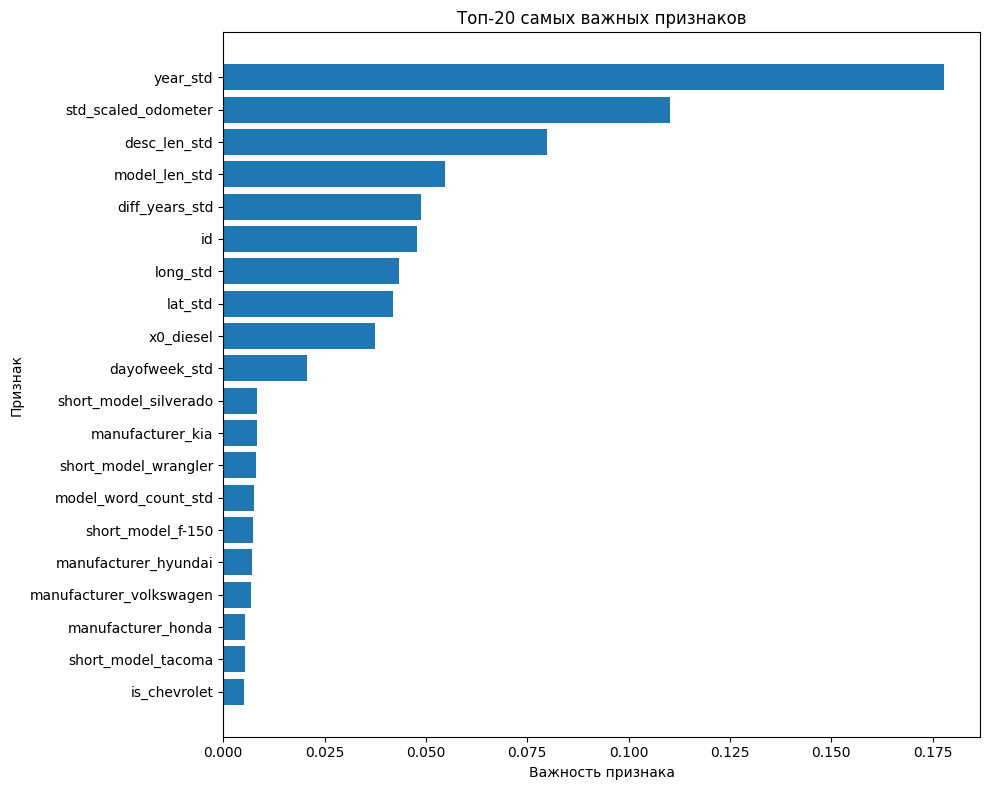

In [56]:
fig, ax = plt.subplots(figsize=(10, 8)) # Увеличим размер для лучшей читаемости

# Для barh лучше отсортировать в обратном порядке, чтобы самые важные были сверху
top_20_features = features.head(20).iloc[::-1]

ax.barh(top_20_features.index, top_20_features.values)
ax.set_xlabel('Важность признака')
ax.set_ylabel('Признак')
ax.set_title('Топ-20 самых важных признаков')
plt.tight_layout() # Автоматически корректирует параметры подложки для плотного размещения графиков.
plt.show()